In [2]:
pip install scikit-learn

  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 23.8 MB/s  0:00:00
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/37.4 MB 21.4 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/37.4 MB 21.0 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/37.4 MB 22.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/37.4 MB 22.4 MB/s eta 0:00:01
   -------------------------- ------------- 24.4/37.4 MB 22.6 MB/s eta 0:00:01
   ------------------------------ --------- 28.6/37.4 MB 22.3 MB/s eta 0:00:01
   ----------------------------------- ---- 33.3/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [4]:
df = pd.read_csv("leads_reales_clean.csv")
df.head(10)


,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,2024,Febrero,543,108,33,0,1,389,1,12,3.1,72
1,2024,Marzo,178,37,13,0,0,128,1,7,5.5,72
2,2024,Abril,416,79,46,3,0,288,1,8,2.8,69
3,2024,Mayo,422,33,100,17,0,274,5,13,4.7,65
4,2024,Junio,967,140,173,31,3,620,17,6,1.0,64
5,2024,Julio,954,112,251,12,9,570,5,21,3.7,60
6,2024,Agosto,1409,504,324,17,18,546,22,17,3.1,39
7,2024,Septiembre,1315,431,314,14,26,530,42,17,3.2,40
8,2024,Octubre,1973,514,606,18,13,822,72,23,2.8,42
9,2024,Noviembre,1562,153,321,44,4,1040,79,22,2.1,67


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Año            28 non-null     int64  
 1   Mes            28 non-null     str    
 2   Total          28 non-null     int64  
 3   Ilocalizable   28 non-null     int64  
 4   No_Contesta    28 non-null     int64  
 5   D_Incorrectos  28 non-null     int64  
 6   Duplicados     28 non-null     int64  
 7   Efectivos      28 non-null     int64  
 8   Abiertos       28 non-null     int64  
 9   Ventas         28 non-null     int64  
 10  Conversion     28 non-null     float64
 11  Efectividad    28 non-null     int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 2.8 KB


,Año,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2024.785714,1122.857143,143.178571,209.428571,19.107143,33.857143,660.142857,250.107143,26.964286,4.142857,61.642857
std,0.738223,421.939939,143.704185,153.734844,19.345474,32.244109,211.922018,236.059839,11.083796,1.249720,11.907714
min,2024.000000,178.000000,5.000000,13.000000,0.000000,0.000000,128.000000,1.000000,6.000000,1.000000,39.000000
25%,2024.000000,946.750000,44.250000,103.000000,3.000000,12.000000,564.000000,37.000000,19.250000,3.275000,52.750000
50%,2025.000000,1170.500000,110.000000,185.500000,13.000000,27.000000,704.500000,200.500000,30.000000,4.050000,64.000000
75%,2025.000000,1397.000000,154.250000,278.000000,31.750000,53.000000,738.000000,368.000000,36.250000,5.275000,70.000000
max,2026.000000,1973.000000,514.000000,606.000000,62.000000,136.000000,1040.000000,823.000000,41.000000,5.900000,83.000000


In [6]:
df.isnull().sum()

Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64

Imputar los valores nulos de la columna “Año” con el numero del año correpondiente y convertir la columna a tipo numérico

In [ ]:
#ya se hizo ese proceso en la limpieza, lo único que añadi es asegurar que sean
#de tipo numérico

df['Año'] = df['Año'].astype(int)

Reemplazar los valores categóricos de la columna “Mes” con el numero del mes correpondiente y convertir la columna a tipo numérico

In [10]:
print(df.columns.tolist())

['Año', 'Mes', 'Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos', 'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion', 'Efectividad']


In [16]:
#Hacemos un diccionario para asignar el número de mes
meses_dict = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

#Reemplazamos los valores categóricos por su número de mes
df['Mes'] = df['Mes'].replace(meses_dict)

#Convertimos la columna a tipo numérico
df['Mes'] = df['Mes'].astype(int)


In [17]:
df[['Año','Mes']].head(15)

,Año,Mes
0,2024,2
1,2024,3
2,2024,4
3,2024,5
4,2024,6
5,2024,7
6,2024,8
7,2024,9
8,2024,10
9,2024,11


In [18]:
#Verificamos los tipos de datos finales de Año y Mes
df.dtypes

Año                int64
Mes                int64
Total              int64
Ilocalizable       int64
No_Contesta        int64
D_Incorrectos      int64
Duplicados         int64
Efectivos          int64
Abiertos           int64
Ventas             int64
Conversion       float64
Efectividad        int64
dtype: object

Procesamiento de outliers

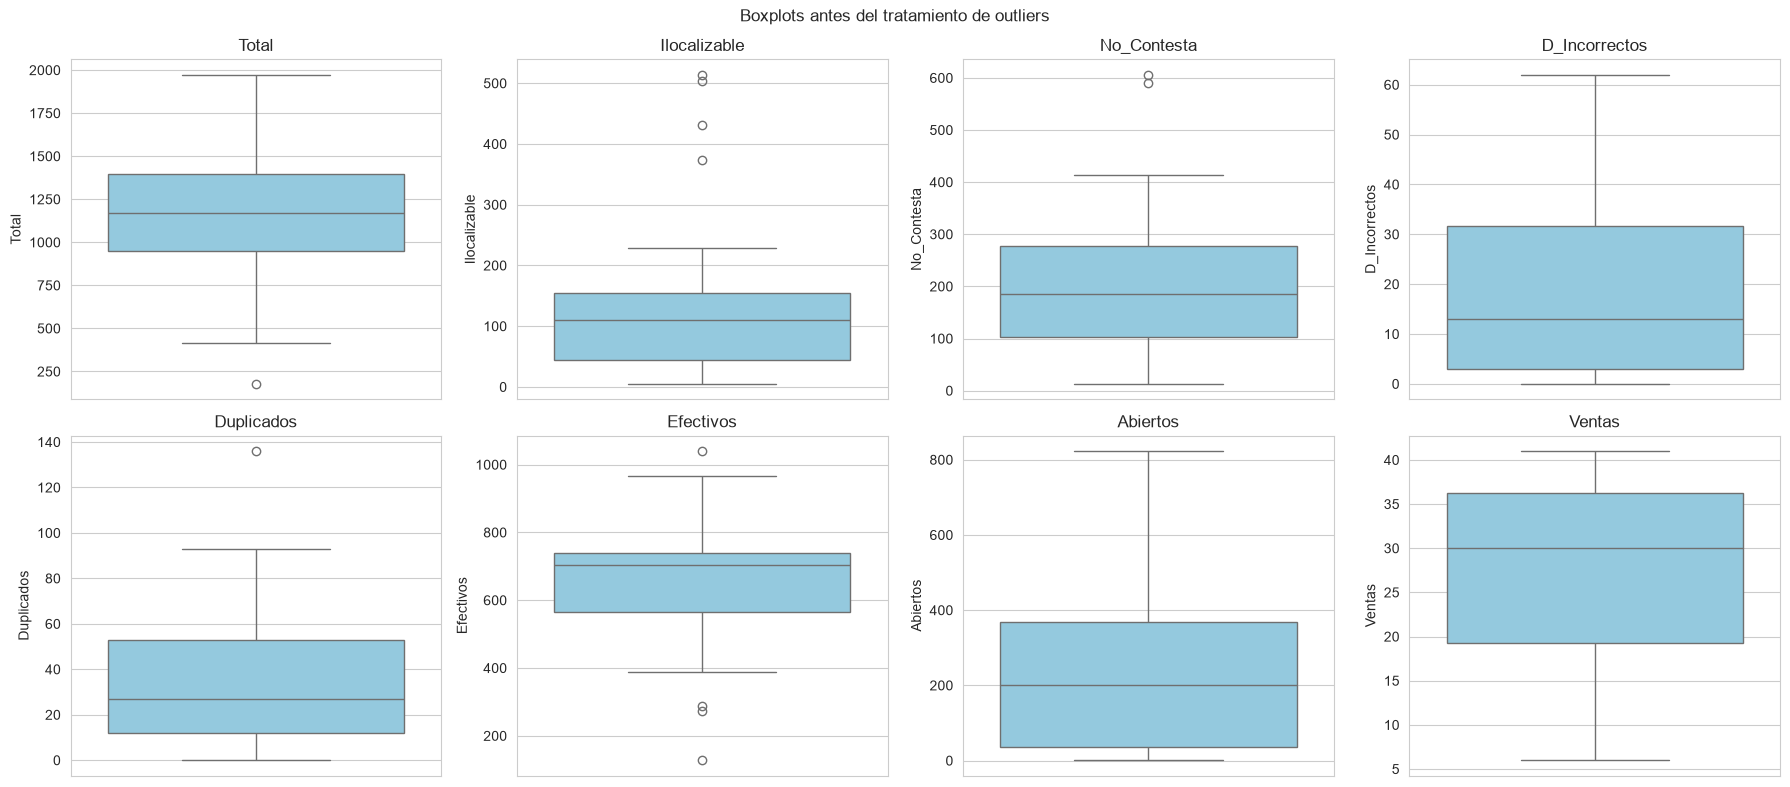

In [19]:
#Columnas numéricas de interés (tipos de Leads + Ventas)
leads_cols = ['Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos',
              'Duplicados', 'Efectivos', 'Abiertos', 'Ventas']

#Visualizamos los boxplots antes de tratar los outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), leads_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.suptitle('Boxplots antes del tratamiento de outliers')
plt.tight_layout()
plt.show()

In [20]:
#Función para detectar límites de outliers con el método IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    return limite_inf, limite_sup

#Reporte de outliers detectados por columna
for col in leads_cols:
    li, ls = limites_iqr(df[col])
    outliers = df[(df[col] < li) | (df[col] > ls)]
    print(f"{col}: {len(outliers)} outlier(s) | límites=({li:.1f}, {ls:.1f})")


Total: 1 outlier(s) | límites=(271.4, 2072.4)
Ilocalizable: 4 outlier(s) | límites=(-120.8, 319.2)
No_Contesta: 2 outlier(s) | límites=(-159.5, 540.5)
D_Incorrectos: 0 outlier(s) | límites=(-40.1, 74.9)
Duplicados: 1 outlier(s) | límites=(-49.5, 114.5)
Efectivos: 4 outlier(s) | límites=(303.0, 999.0)
Abiertos: 0 outlier(s) | límites=(-459.5, 864.5)
Ventas: 0 outlier(s) | límites=(-6.2, 61.8)


In [21]:
#Tratamos los outliers mediante 'capping' (Winsorización):
#los valores fuera de los límites se ajustan al límite más cercano.
#Se eligió este método (en lugar de eliminar filas) porque el dataset es pequeño (28 meses)
#y los valores altos reflejan crecimiento real del negocio, no errores de captura.

df_clean = df.copy()
for col in leads_cols:
    li, ls = limites_iqr(df[col])
    df_clean[col] = df_clean[col].clip(lower=li, upper=ls)

df = df_clean

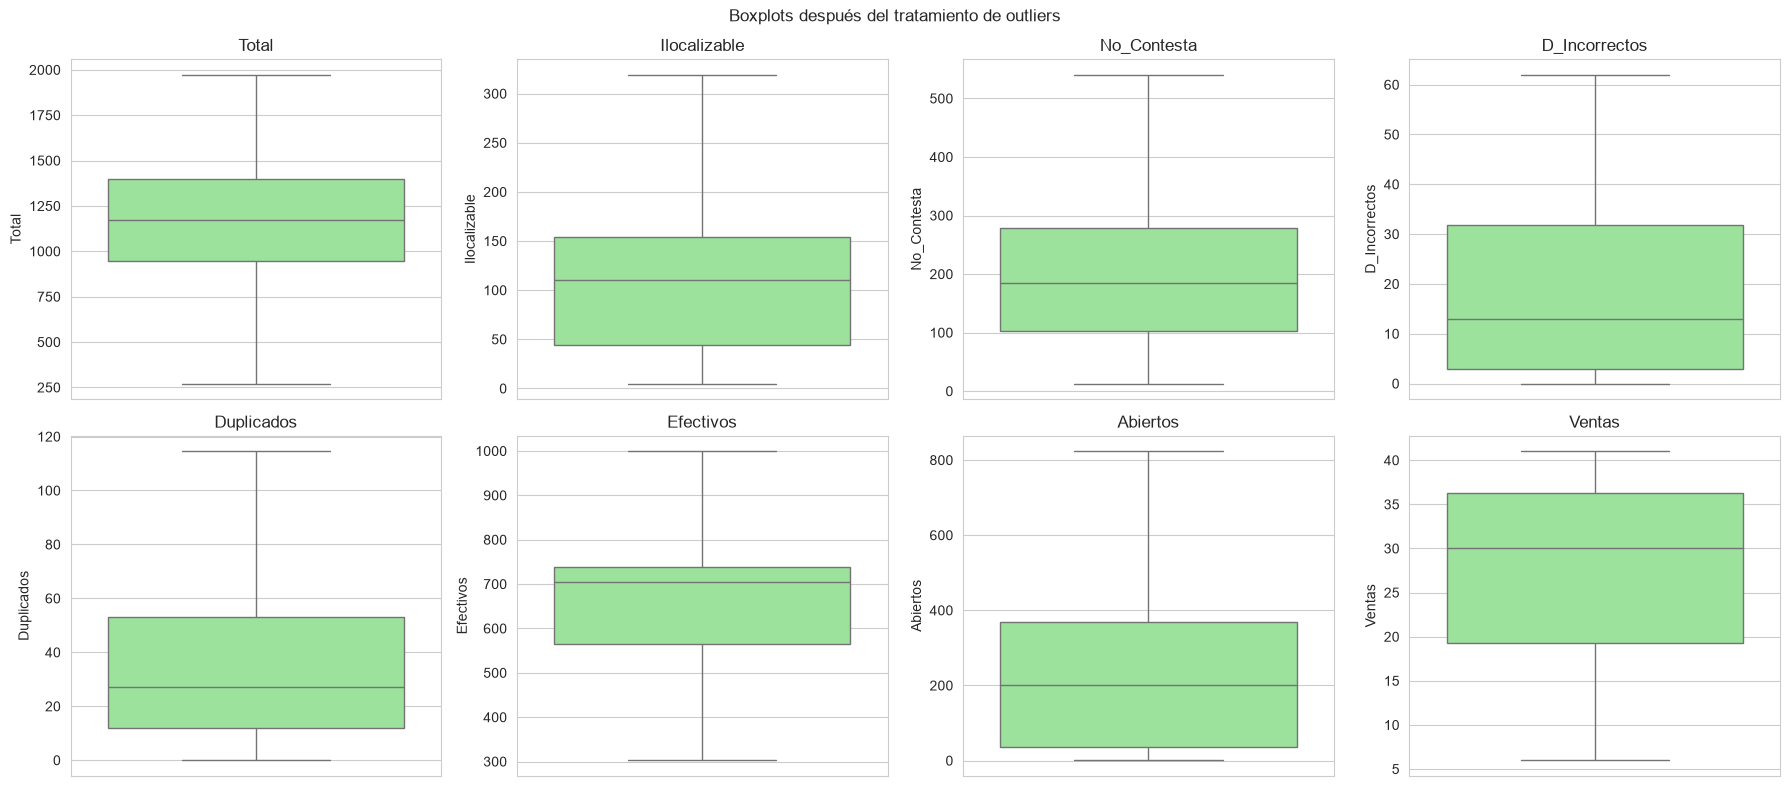

In [22]:
#Visualizamos los boxplots después del tratamiento de outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), leads_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.suptitle('Boxplots después del tratamiento de outliers')
plt.tight_layout()
plt.show()


Analizar la correlación 

In [23]:
#Matriz de correlación de todas las variables numéricas
Corr_Factors = df.corr(numeric_only=True)
Corr_Factors

,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
Año,1.000000,-0.371581,0.341666,-0.168942,-0.126365,0.180612,0.393646,0.391459,0.800323,0.745898,0.536228,-0.105934
Mes,-0.371581,1.000000,0.417637,0.377843,0.661820,0.000990,-0.107904,0.347938,0.054022,0.184924,-0.077131,-0.302947
Total,0.341666,0.417637,1.000000,0.634333,0.649204,0.452898,0.282499,0.797405,0.529062,0.529132,-0.126933,-0.658255
Ilocalizable,-0.168942,0.377843,0.634333,1.000000,0.376287,0.403795,-0.139535,0.329573,0.081877,-0.038604,-0.417358,-0.629870
No_Contesta,-0.126365,0.661820,0.649204,0.376287,1.000000,-0.033819,0.033793,0.380111,0.022429,0.242103,-0.074802,-0.613243
D_Incorrectos,0.180612,0.000990,0.452898,0.403795,-0.033819,1.000000,0.250698,0.470689,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.393646,-0.107904,0.282499,-0.139535,0.033793,0.250698,1.000000,0.509139,0.366046,0.488915,0.104046,0.134374
Efectivos,0.391459,0.347938,0.797405,0.329573,0.380111,0.470689,0.509139,1.000000,0.508191,0.654054,-0.102551,-0.098226
Abiertos,0.800323,0.054022,0.529062,0.081877,0.022429,0.382420,0.366046,0.508191,1.000000,0.752551,0.445734,-0.281941
Ventas,0.745898,0.184924,0.529132,-0.038604,0.242103,0.143903,0.488915,0.654054,0.752551,1.000000,0.626595,-0.115155


In [24]:
#Valor absoluto de las correlaciones
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1

,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
Año,1.000000,0.371581,0.341666,0.168942,0.126365,0.180612,0.393646,0.391459,0.800323,0.745898,0.536228,0.105934
Mes,0.371581,1.000000,0.417637,0.377843,0.661820,0.000990,0.107904,0.347938,0.054022,0.184924,0.077131,0.302947
Total,0.341666,0.417637,1.000000,0.634333,0.649204,0.452898,0.282499,0.797405,0.529062,0.529132,0.126933,0.658255
Ilocalizable,0.168942,0.377843,0.634333,1.000000,0.376287,0.403795,0.139535,0.329573,0.081877,0.038604,0.417358,0.629870
No_Contesta,0.126365,0.661820,0.649204,0.376287,1.000000,0.033819,0.033793,0.380111,0.022429,0.242103,0.074802,0.613243
D_Incorrectos,0.180612,0.000990,0.452898,0.403795,0.033819,1.000000,0.250698,0.470689,0.382420,0.143903,0.247300,0.177488
Duplicados,0.393646,0.107904,0.282499,0.139535,0.033793,0.250698,1.000000,0.509139,0.366046,0.488915,0.104046,0.134374
Efectivos,0.391459,0.347938,0.797405,0.329573,0.380111,0.470689,0.509139,1.000000,0.508191,0.654054,0.102551,0.098226
Abiertos,0.800323,0.054022,0.529062,0.081877,0.022429,0.382420,0.366046,0.508191,1.000000,0.752551,0.445734,0.281941
Ventas,0.745898,0.184924,0.529132,0.038604,0.242103,0.143903,0.488915,0.654054,0.752551,1.000000,0.626595,0.115155


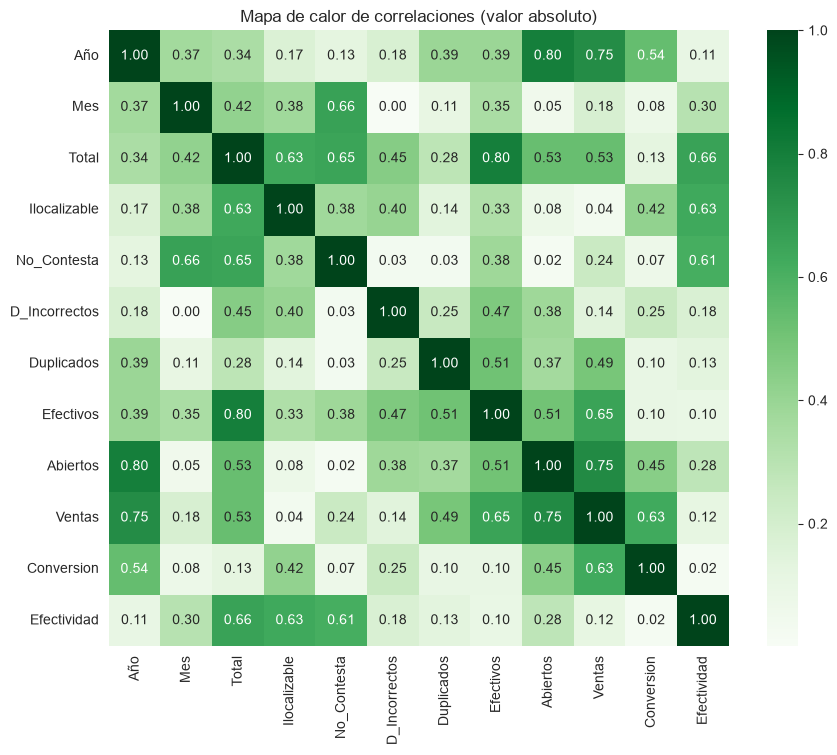

In [25]:
#Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
Heat_Map = sns.heatmap(Corr_Factors1, cmap='Greens', annot=True, fmt=".2f")
plt.title('Mapa de calor de correlaciones (valor absoluto)')
plt.show()

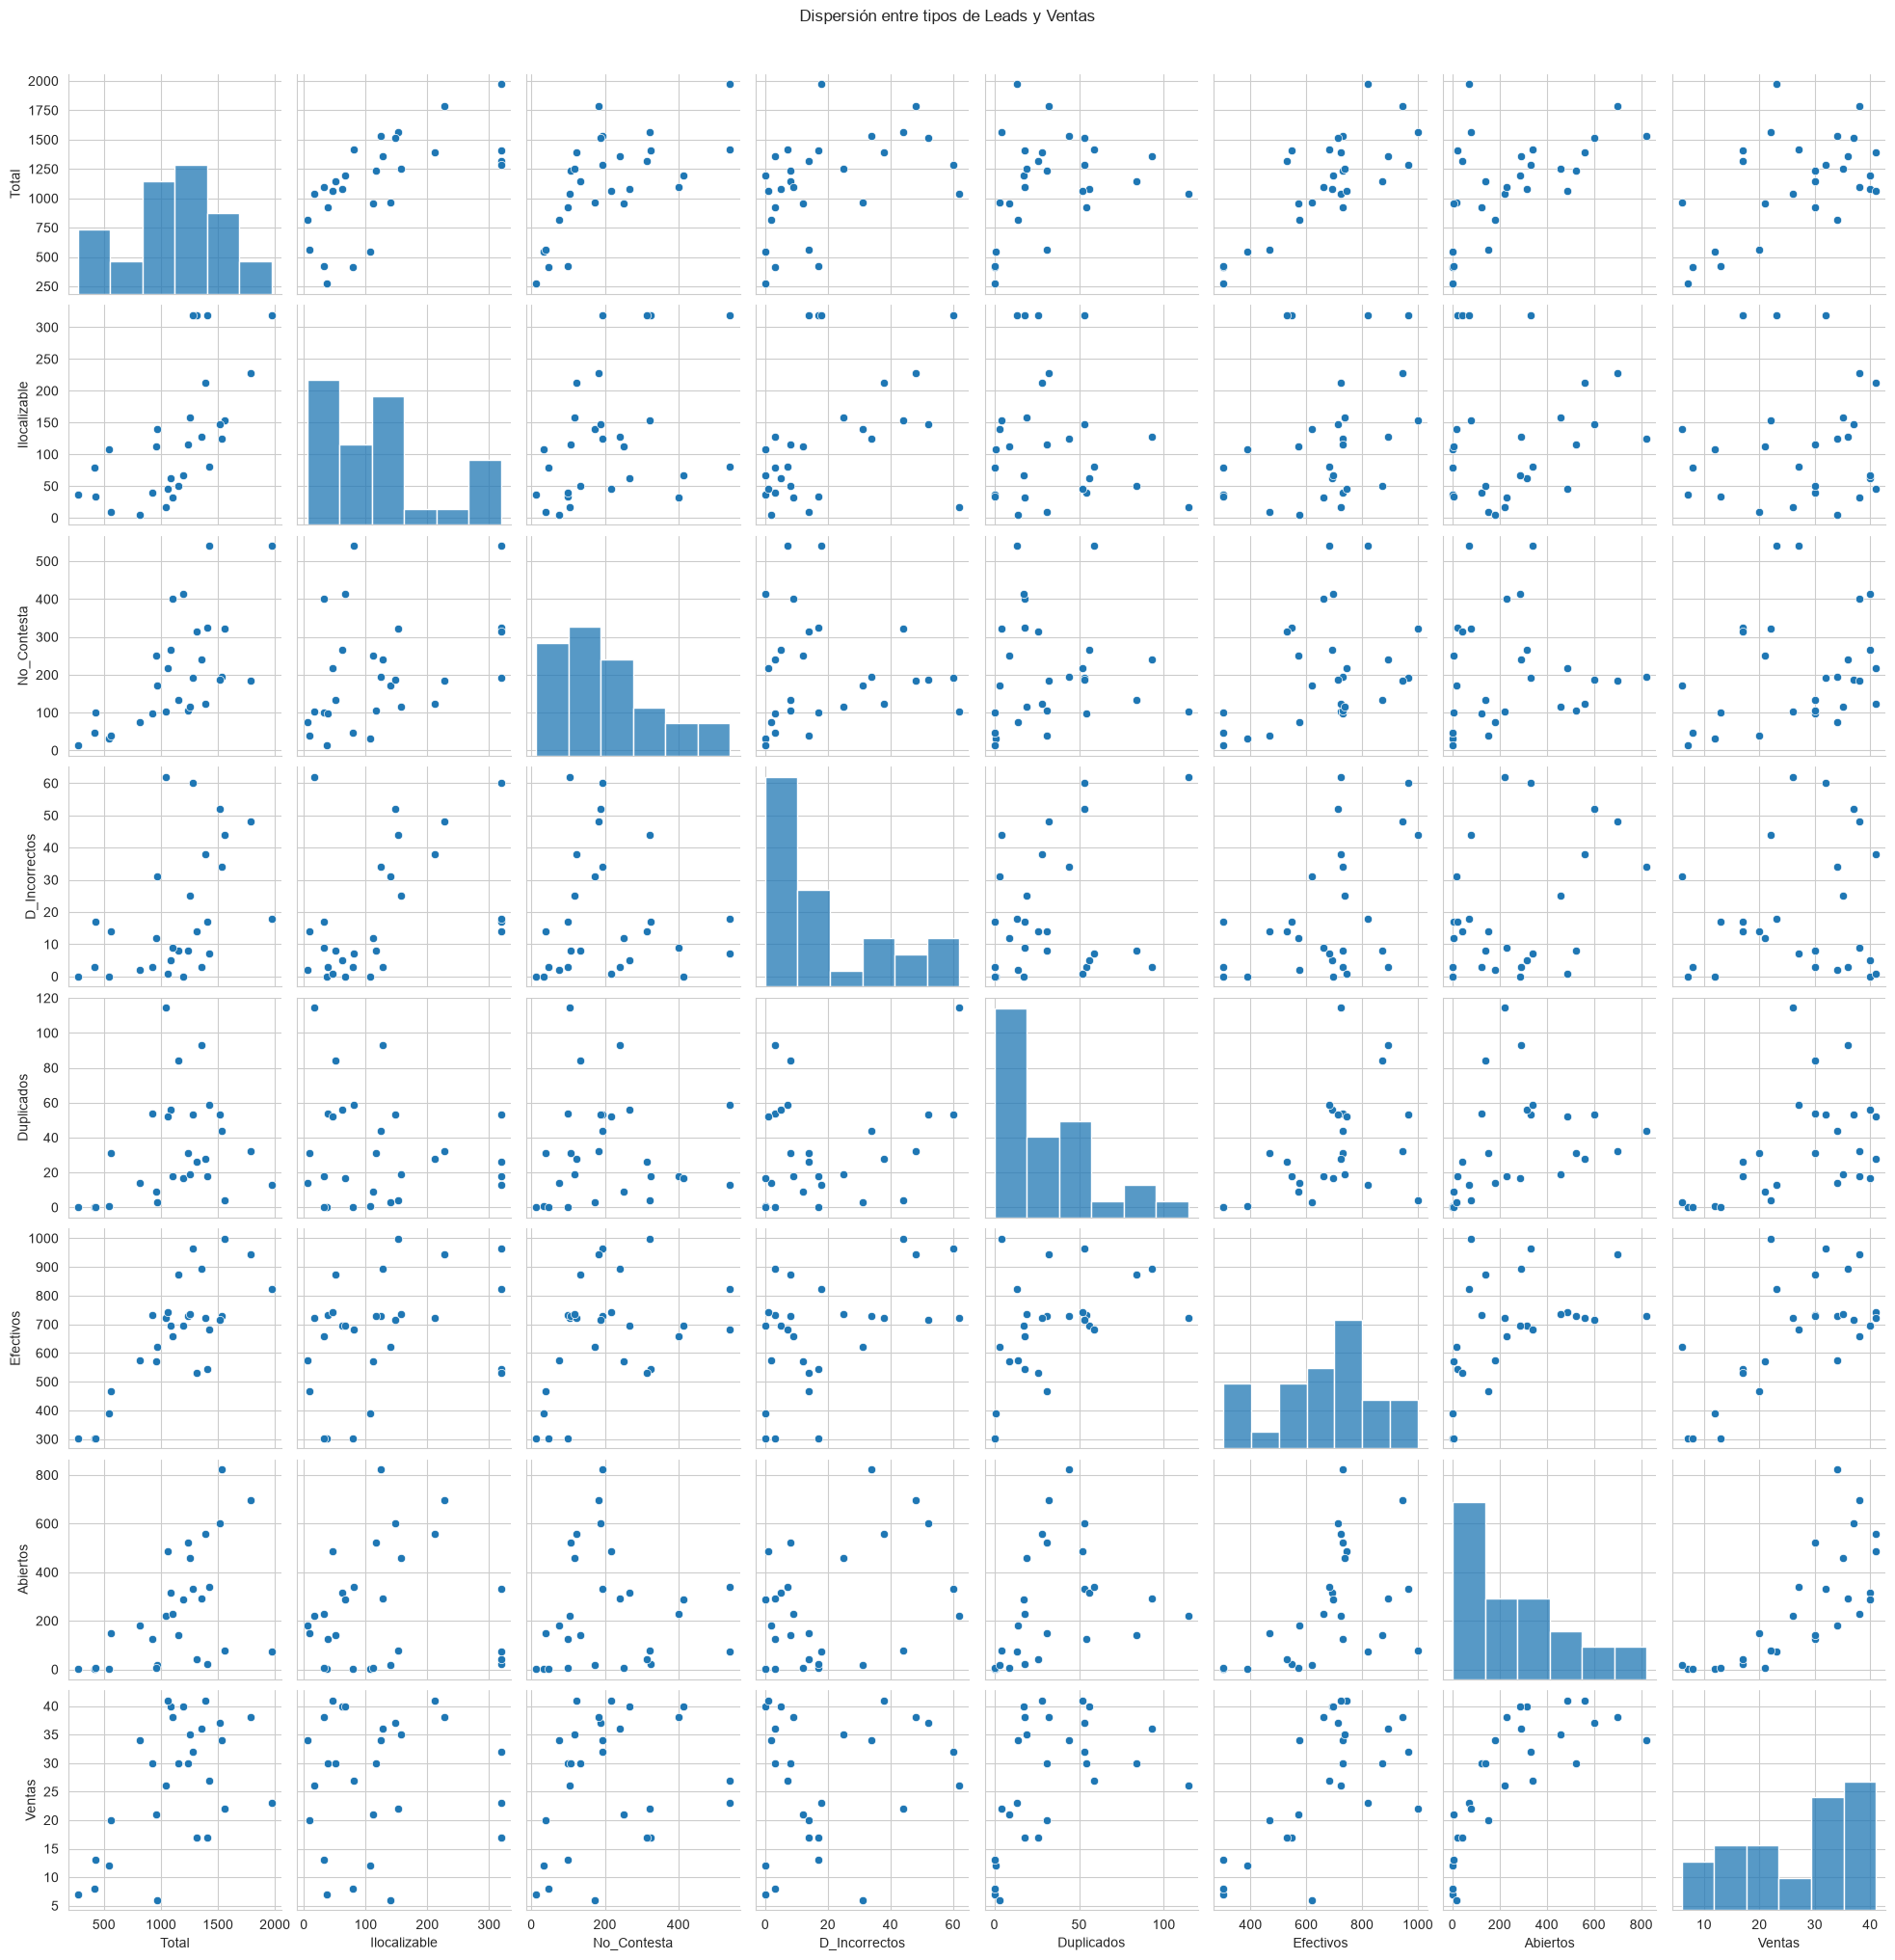

In [26]:
#Graficamos todas las dispersiones entre variables
sns.pairplot(df[leads_cols])
plt.suptitle('Dispersión entre tipos de Leads y Ventas', y=1.02)
plt.show()

In [27]:
#Correlación específica de cada tipo de Lead respecto a Ventas (variable dependiente)
tipos_leads = ['Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos', 'Duplicados', 'Efectivos', 'Abiertos']

corr_ventas = df[tipos_leads + ['Ventas']].corr()['Ventas'].drop('Ventas').sort_values(ascending=False)
corr_ventas


Abiertos         0.752551
Efectivos        0.654054
Total            0.529132
Duplicados       0.488915
No_Contesta      0.242103
D_Incorrectos    0.143903
Ilocalizable    -0.038604
Name: Ventas, dtype: float64

C:\Users\hdzmi\AppData\Local\Temp\ipykernel_3240\2761835495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_ventas.values, y=corr_ventas.index, palette=colors)


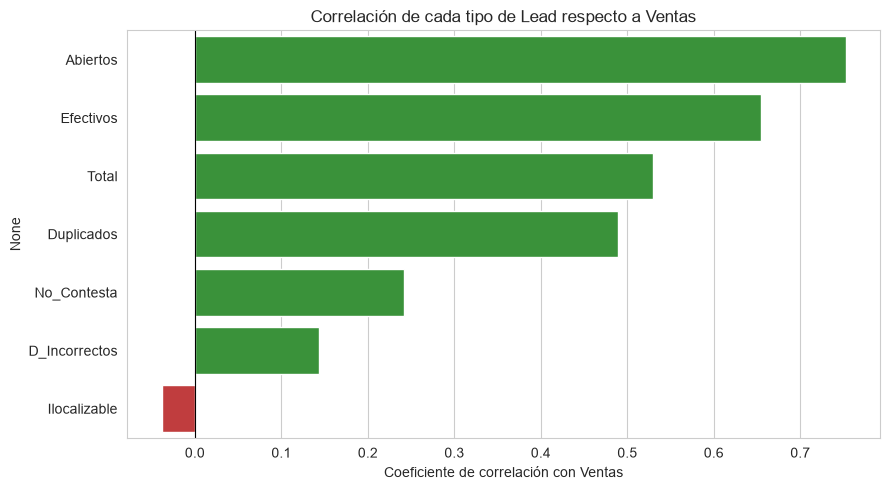

In [28]:
#Graficamos la correlación de cada tipo de Lead respecto a Ventas
plt.figure(figsize=(9, 5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in corr_ventas.values]
sns.barplot(x=corr_ventas.values, y=corr_ventas.index, palette=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente de correlación con Ventas')
plt.title('Correlación de cada tipo de Lead respecto a Ventas')
plt.tight_layout()
plt.show()

Regresión simple por tipo de lead

In [29]:
#Declaramos la variable dependiente
Var_Dep = df['Ventas']

#Ajustamos un modelo de Regresión Lineal Simple por cada tipo de Lead
resultados = []

for col in tipos_leads:
    Vars_Indep = df[[col]]

    model = LinearRegression()
    model.fit(X=Vars_Indep, y=Var_Dep)

    coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)
    coef_Correl = np.sqrt(coef_Deter) if model.coef_[0] >= 0 else -np.sqrt(coef_Deter)

    resultados.append({
        'Tipo_Lead': col,
        'Pendiente (m)': model.coef_[0],
        'Intercepto (b)': model.intercept_,
        'Coef_Determinacion_R2': coef_Deter,
        'Coef_Correlacion_r': coef_Correl
    })

Resumen_Modelos = pd.DataFrame(resultados).sort_values('Coef_Determinacion_R2', ascending=False).reset_index(drop=True)
Resumen_Modelos

,Tipo_Lead,Pendiente (m),Intercepto (b),Coef_Determinacion_R2,Coef_Correlacion_r
0,Abiertos,0.035335,18.126805,0.566333,0.752551
1,Efectivos,0.037785,1.780679,0.427787,0.654054
2,Total,0.014149,11.029666,0.279981,0.529132
3,Duplicados,0.181288,20.965580,0.239038,0.488915
4,No_Contesta,0.018733,23.118587,0.058614,0.242103
5,D_Incorrectos,0.082448,25.388946,0.020708,0.143903
6,Ilocalizable,-0.004302,27.496332,0.001490,-0.038604


In [30]:
#Identificamos el tipo de Lead con mayor poder predictivo sobre las Ventas
mejor_predictor = Resumen_Modelos.iloc[0]['Tipo_Lead']
print(f"El tipo de Lead con mayor relación lineal con las Ventas es: '{mejor_predictor}'")
print(Resumen_Modelos.iloc[0])

El tipo de Lead con mayor relación lineal con las Ventas es: 'Abiertos'
Tipo_Lead                 Abiertos
Pendiente (m)             0.035335
Intercepto (b)           18.126805
Coef_Determinacion_R2     0.566333
Coef_Correlacion_r        0.752551
Name: 0, dtype: object


Modelo detallado-ventas con mayor predictor

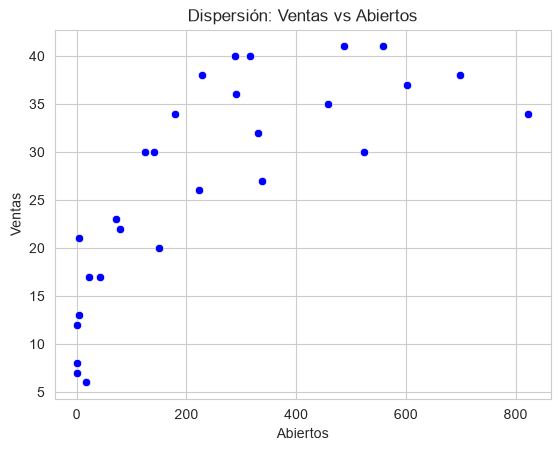

In [31]:
#Imprimimos el scatter plot entre la variable dependiente (Ventas) y la independiente (mejor predictor)
sns.scatterplot(x=mejor_predictor, y='Ventas', color='blue', data=df)
plt.title(f'Dispersión: Ventas vs {mejor_predictor}')
plt.show()

In [32]:
#Declaramos las variables dependiente e independiente para el modelo final
Vars_Indep = df[[mejor_predictor]]
Var_Dep = df['Ventas']

#Ajustamos el modelo de Regresión Lineal Simple
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)

#Verificamos los coeficientes obtenidos
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abiertos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03533478]),
 'rank_': np.int64(1),
 'singular_': array([1226.60290175]),
 'intercept_': np.float64(18.126805081456116)}

In [33]:
#Ecuación del modelo matemático obtenido
m = model.coef_[0]
b = model.intercept_
print(f"Modelo matemático: Ventas = {m:.4f} * {mejor_predictor} + {b:.4f}")


Modelo matemático: Ventas = 0.0353 * Abiertos + 18.1268


In [34]:
#Evaluamos la eficiencia del modelo con el coeficiente de Determinación (R2)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Deter

0.5663330934367705

In [35]:
#Corroboramos el coeficiente de Correlación del modelo
coef_Correl = np.sqrt(coef_Deter)
coef_Correl

np.float64(0.7525510570298672)

In [36]:
#Predecimos los valores de Ventas a partir del mejor predictor
y_pred = model.predict(X=Vars_Indep)

#Insertamos la columna de predicciones en el DataFrame
df_resultado = df.copy()
df_resultado.insert(0, 'Predicciones_Ventas', y_pred)
df_resultado[[mejor_predictor, 'Ventas', 'Predicciones_Ventas']].head(10)

,Abiertos,Ventas,Predicciones_Ventas
0,1,12,18.162140
1,1,7,18.162140
2,1,8,18.162140
3,5,13,18.303479
4,17,6,18.727496
5,5,21,18.303479
6,22,17,18.904170
7,42,17,19.610866
8,72,23,20.670909
9,79,22,20.918253


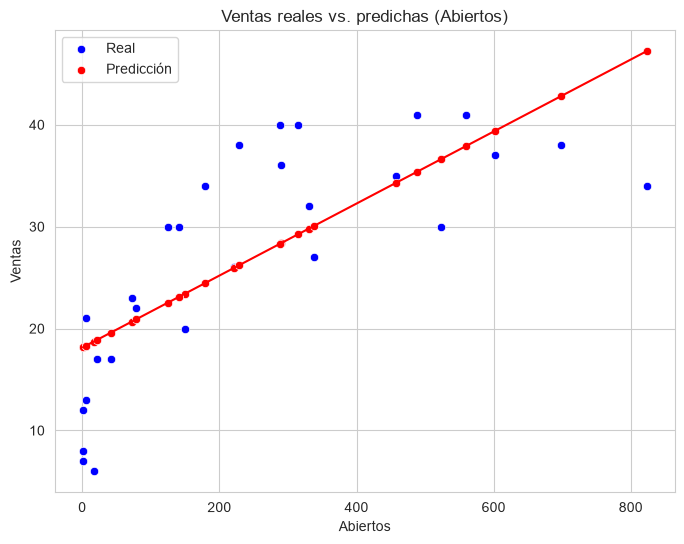

In [37]:
#Visualizamos la gráfica comparativa entre las Ventas reales y las predichas
plt.figure(figsize=(8,6))
sns.scatterplot(x=mejor_predictor, y='Ventas', color='blue', data=df_resultado, label='Real')
sns.scatterplot(x=mejor_predictor, y='Predicciones_Ventas', color='red', data=df_resultado, label='Predicción')
sns.lineplot(x=mejor_predictor, y='Predicciones_Ventas', color='red', data=df_resultado)
plt.title(f'Ventas reales vs. predichas ({mejor_predictor})')
plt.legend()
plt.show()

In [40]:
print("HALLAZGOS PRINCIPALES")
print("="*60)
print(f"1. El tipo de Lead más correlacionado con las Ventas es '{mejor_predictor}'")
print(f"   R2 = {coef_Deter:.4f}  |  r = {coef_Correl:.4f}")
print()
print("2. Ranking de todos los tipos de Lead según su relación con Ventas:")
print(Resumen_Modelos.to_string(index=False))


HALLAZGOS PRINCIPALES
1. El tipo de Lead más correlacionado con las Ventas es 'Abiertos'
   R2 = 0.5663  |  r = 0.7526

2. Ranking de todos los tipos de Lead según su relación con Ventas:
    Tipo_Lead  Pendiente (m)  Intercepto (b)  Coef_Determinacion_R2  Coef_Correlacion_r
     Abiertos       0.035335       18.126805               0.566333            0.752551
    Efectivos       0.037785        1.780679               0.427787            0.654054
        Total       0.014149       11.029666               0.279981            0.529132
   Duplicados       0.181288       20.965580               0.239038            0.488915
  No_Contesta       0.018733       23.118587               0.058614            0.242103
D_Incorrectos       0.082448       25.388946               0.020708            0.143903
 Ilocalizable      -0.004302       27.496332               0.001490           -0.038604
